In [2]:
%pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 63.4 MB/s eta 0:00:00


In [13]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import networkx as nx

from torch_geometric.data import Data
from torch_geometric.utils import to_networkx, to_dense_adj

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print("PyTorch version:", torch.__version__)
print("PyTorch Geometric version:", torch.__version__)

PyTorch version: 2.10.0+cpu
PyTorch Geometric version: 2.10.0+cpu


In [14]:
def make_sbm_graph(n_nodes, block_sizes, p_intra, p_inter):
    """
    Generates a single snapshot of a stochastic block model

    Args:
        n_nodes (int): The total number of nodes in the graph (must equal sum of block_sizes)
        block_sizes (list of int): The number of nodes in each block
        e.g. [10, 10] for 2 communities of 10
        p_intra (float): The probability of an edge within a block (e.g. 0.8 for dense communities)
        p_inter (float): The probability of an edge between blocks (e.g. 0.1 for sparse inter-community connections)

    Returns:
        Data: A PyTorch Geometric Data object representing the graph
    """
    # sizes = how many nodes in each block
    # probs = probability of edges within and between blocks
    sizes = block_sizes
    probs = [
        [p_intra if i == j else p_inter for j in range(len(block_sizes))]
        for i in range(len(block_sizes))
    ]

    G = nx.stochastic_block_model(sizes, probs, seed=SEED)
    return G

In [15]:
def evolve_graph(G_prev, p_flip):
    """
    Evolves the graph by randomly flipping edges with a given probability
    Each existing edge is removed with probability p_flip.
    Each non-edge is added with probability p_flip.

    This simulates slow structural change — the graph
    doesn't jump to a completely new structure, it drifts.

    Args:
        G_prev (networkx.Graph): The previous graph snapshot
        p_flip (float): The probability of flipping each edge (e.g. 0.05 for 5% chance)

    Returns:
        networkx.Graph: The evolved graph snapshot
    """
    G_new = G_prev.copy()
    nodes = list(G_prev.nodes())

    for i in nodes:
        for j in nodes:
            if i < j:  # Avoid double counting and self-loops
                if np.random.rand() < p_flip:
                    if G_prev.has_edge(i, j):
                        G_new.remove_edge(i, j)
                    else:
                        G_new.add_edge(i, j)
    return G_new

In [16]:
def generate_sequence(n_nodes, block_sizes, p_intra, p_inter, p_flip, T):
    """
    Generates a sequence of evolving graphs

    Args:
        n_nodes (int): Total number of nodes in the graph
        block_sizes (list of int): Sizes of each community block
        p_intra (float): Probability of edges within blocks
        p_inter (float): Probability of edges between blocks
        p_flip (float): Probability of flipping edges at each step
        T (int): number of timesteps (length of sequence)

    Returns:
        list of networkx.Graph: A list of evolved graph snapshots [G_0, G_1, ..., G_{T-1}]
    """
    G0 = make_sbm_graph(n_nodes, block_sizes, p_intra, p_inter)
    sequence = [G0]
    for _ in range(T -1):
        G_next = evolve_graph(sequence[-1], p_flip)
        sequence.append(G_next)
    return sequence

In [17]:
N_NODES = 20
BLOCK_SIZES = [10, 10]  # Two communities of 10 nodes each
P_INTRA = 0.7  # High probability of edges within communities
P_INTER = 0.05  # Low probability of edges between communities
P_FLIP = 0.1  # 10% chance to flip each edge at each step
T = 20  # time steps per sequence

seq = generate_sequence(N_NODES, BLOCK_SIZES, P_INTRA, P_INTER, P_FLIP, T)
print(f"Generated a sequence of {len(seq)} graphs, each with {N_NODES} nodes.")
print(f"Nodes at t=0 : {seq[0].number_of_nodes()}")
print(f"Edges at t=0 : {seq[0].number_of_edges()}")
print(f"Edges at t=5 : {seq[5].number_of_edges()}")
print(f"Edges at t=19: {seq[19].number_of_edges()}")

Generated a sequence of 20 graphs, each with 20 nodes.
Nodes at t=0 : 20
Edges at t=0 : 71
Edges at t=5 : 97
Edges at t=19: 105


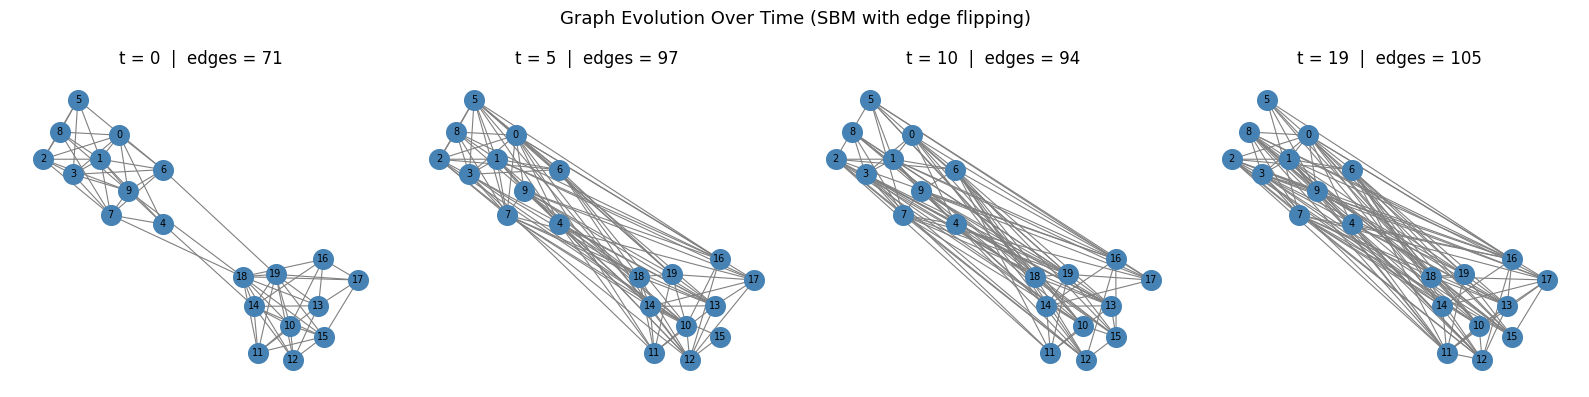

In [18]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
timesteps_to_plot = [0, 5, 10, 19]

# Fix the node layout so positions don't change between plots
# spring_layout computes (x,y) positions once; we reuse them
pos = nx.spring_layout(seq[0], seed=SEED)

for ax, t in zip(axes, timesteps_to_plot):
    nx.draw(
        seq[t], pos=pos, ax=ax,
        node_color='steelblue', node_size=200,
        edge_color='gray', width=0.8, with_labels=True, font_size=7
    )
    ax.set_title(f"t = {t}  |  edges = {seq[t].number_of_edges()}")

plt.suptitle("Graph Evolution Over Time (SBM with edge flipping)", fontsize=13)
plt.tight_layout()
plt.show()

In [19]:
def graph_to_pyg(G, n_nodes):
    """
    Converts a NetworkX graph into a PyTorch Geometric Data object.

    In PyG, graphs are stored in COO (Coordinate) format:
        edge_index : shape [2, num_edges]
                     edge_index[0] = source nodes
                     edge_index[1] = destination nodes

    Since we have no natural node features here, we use the
    node degree as a simple 1D feature vector.
    Using degree as a feature is a common proxy — it gives
    the GNN something structural to work with.

    Args:
        G       : NetworkX graph
        n_nodes : total number of nodes (needed to handle isolated nodes)

    Returns:
        data : PyG Data object with fields:
               .x          → node features  [n_nodes, 1]
               .edge_index → edge list      [2, num_edges]
               .num_nodes  → n_nodes
    """
    #features: degree of each node (shape [n_nodes, 1])
    degrees = dict(G.degree())
    x = torch.tensor(
        [[degrees.get(i, 0)] for i in range(n_nodes)],
        dtype=torch.float
    )

    #edges: list of (source, target) pairs
    edges = list(G.edges())
    if len(edges) == 0:
        edge_index = torch.empty((2, 0), dtype=torch.long)
    else:
        src = [u for u, v in edges] + [v for u, v in edges]  # undirected: add both directions
        dst = [v for u, v in edges] + [u for u, v in edges]
        edge_index = torch.tensor([src, dst], dtype=torch.long)

    data = Data(x=x, edge_index=edge_index, num_nodes=n_nodes)
    return data


In [20]:
# Convert the whole sequence
pyg_sequence = [graph_to_pyg(G, N_NODES) for G in seq]

# Build (input, target) pairs:
# Given graph at time t → predict graph at time t+1
pairs = [(pyg_sequence[t], pyg_sequence[t+1]) for t in range(T - 1)]

print(f"Number of (input, target) training pairs: {len(pairs)}")
print(f"\nExample — pair at t=0:")
print(f"  Input  x shape      : {pairs[0][0].x.shape}")
print(f"  Input  edge_index   : {pairs[0][0].edge_index.shape}")
print(f"  Target edge_index   : {pairs[0][1].edge_index.shape}")

Number of (input, target) training pairs: 19

Example — pair at t=0:
  Input  x shape      : torch.Size([20, 1])
  Input  edge_index   : torch.Size([2, 142])
  Target edge_index   : torch.Size([2, 148])
